In [5]:
import numpy as np
import scipy as sp 
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import pandas as pd
import qiskit as qk
from math import gcd, ceil, log2
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import QFTGate, UnitaryGate
from qiskit_aer import AerSimulator

# Qiskit visualization libraries
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector

To implement Shor's algorithm we need a couple of pieces. Shor's algorithm first relies on the quantum order finding problem which itself relies on the quantum phase estimation algorithm. So we can modify the code we have from Q3 to implement the order finding portion of our algorithm (we do some slight modification to make it more suitable to our needs here so we change our outputs and don't assume we know the order in advance here, we do full quantum order finding). 

We find our order r by running the order finding circuit and then using the continued fraction expansion to extract a candidate order from the measurement results. We repeat this process until we find a valid order r that satisfies a^r = 1 mod N. Once we have a valid order r, we can use it to find factors of N by computing gcd(a^(r/2) ± 1, N).

In [16]:

def Ux_matrix(a, N):
    """Unitary matrix for U_a|y> = |a*y mod N> (y < N), identity for y >= N.
    Dimension is 2^m where m = ceil(log2(N))."""
    m = ceil(log2(N))
    dim = 2**m
    U = np.zeros((dim, dim), dtype=complex)
    for y in range(dim):
        target = (a * y) % N if y < N else y
        U[target, y] = 1.0
    return U, m


def QPE_circ(a, N, n_count):
    U, m = Ux_matrix(a, N)

    n_total = n_count + m
    qc = QuantumCircuit(n_total, n_count)

    count_qubits = list(range(n_count))
    work_qubits = list(range(n_count, n_total))

    # Work register in |1>
    qc.x(work_qubits[0])

    # Hadamard on counting register
    qc.h(count_qubits)

    # Controlled-U^(2^j) for each counting qubit
    for j in range(n_count):
        U_pow = np.linalg.matrix_power(U, 2**j)
        cU = UnitaryGate(U_pow, label=f"U^{2**j}").control(1)
        qc.append(cU, [count_qubits[j]] + work_qubits)

    # Inverse QFT -> read out phase
    qc.append(QFTGate(n_count).inverse(), count_qubits)
    qc.measure(count_qubits, range(n_count))
    return qc


def phase_to_order(phase, N):
    """Use continued fractions to extract an order candidate denominator."""
    from fractions import Fraction

    frac = Fraction(phase).limit_denominator(N)
    return frac.denominator


def find_order(a, N, n_count=8, shots=2048, seed=42):
    """Run QPE for a mod N; return the most likely valid order estimate."""
    qc = QPE_circ(a, N, n_count)
    display(qc.draw("mpl"))

    sim = AerSimulator()
    tqc = transpile(qc, sim)
    result = sim.run(tqc, shots=shots, seed_simulator=seed).result()
    counts = result.get_counts()

    # Try each measured bitstring, highest count first
    for bitstr, _ in sorted(counts.items(), key=lambda kv: kv[1], reverse=True):
        k = int(bitstr, 2)
        if k == 0:
            continue
        phase = k / (2**n_count)
        r = phase_to_order(phase, N)
        if r > 0 and pow(a, r, N) == 1:
            return r, counts
    return None, counts


def shors_algorithm(N, n_count=8, shots=2048, seed=42, max_attempts=10, a=None):
    """Factor N using Shor's algorithm.

    If a is provided, use this fixed base. If a is None, sample random bases.
    Returns (p, q) such that p * q = N, or (None, None) if unsuccessful.
    """
    rng = np.random.default_rng(seed)

    #if we know a ahead of time we use it
    if a is not None:
        a = int(a)
        if not (2 <= a < N):
            raise ValueError("a must satisfy 2 <= a < N")
        trial_bases = [a]
    else:
        trial_bases = [int(rng.integers(2, N)) for _ in range(max_attempts)]
    #otherwise we sample at random to try and find a lucky number that shares a factor with N
    for attempt, base in enumerate(trial_bases, start=1):
        g = gcd(base, N)
        if g > 1:
            print(f"Lucky guess: gcd({base},{N}) = {g}")
            return g, N // g

        print(f"Attempt {attempt}: a={base}")
        #run our order finding subroutine (this is the first part of the algorithm)
        r, _ = find_order(base, N, n_count=n_count, shots=shots, seed=seed + attempt - 1)
        print(f"  Estimated order r={r}")

        #progress check in case our order finding subroutine fails to give us a good estimate
        if r is None or r % 2 != 0:
            print("  r is None or odd - retrying")
            continue
        
        #get our factors from our order estimate (this is the second part of the algorithm)
        x = pow(base, r // 2, N)
        #progress check in case our order estimate is not good enough to give us nontrivial factors
        if x == N - 1:
            print("  a^(r/2) == -1 mod N - retrying")
            continue
        

        p = gcd(x - 1, N)
        q = gcd(x + 1, N)
        if 1 < p < N and 1 < q < N:
            print(f"  Found factors: {p} x {q}")
            return p, q

        print("Factors trivial - retrying")
    #return none if we exhaust our attempts without finding factors
    return None, None

Factoring N = 35 using Shor's algorithm
Using provided a = 2

Attempt 1: a=2


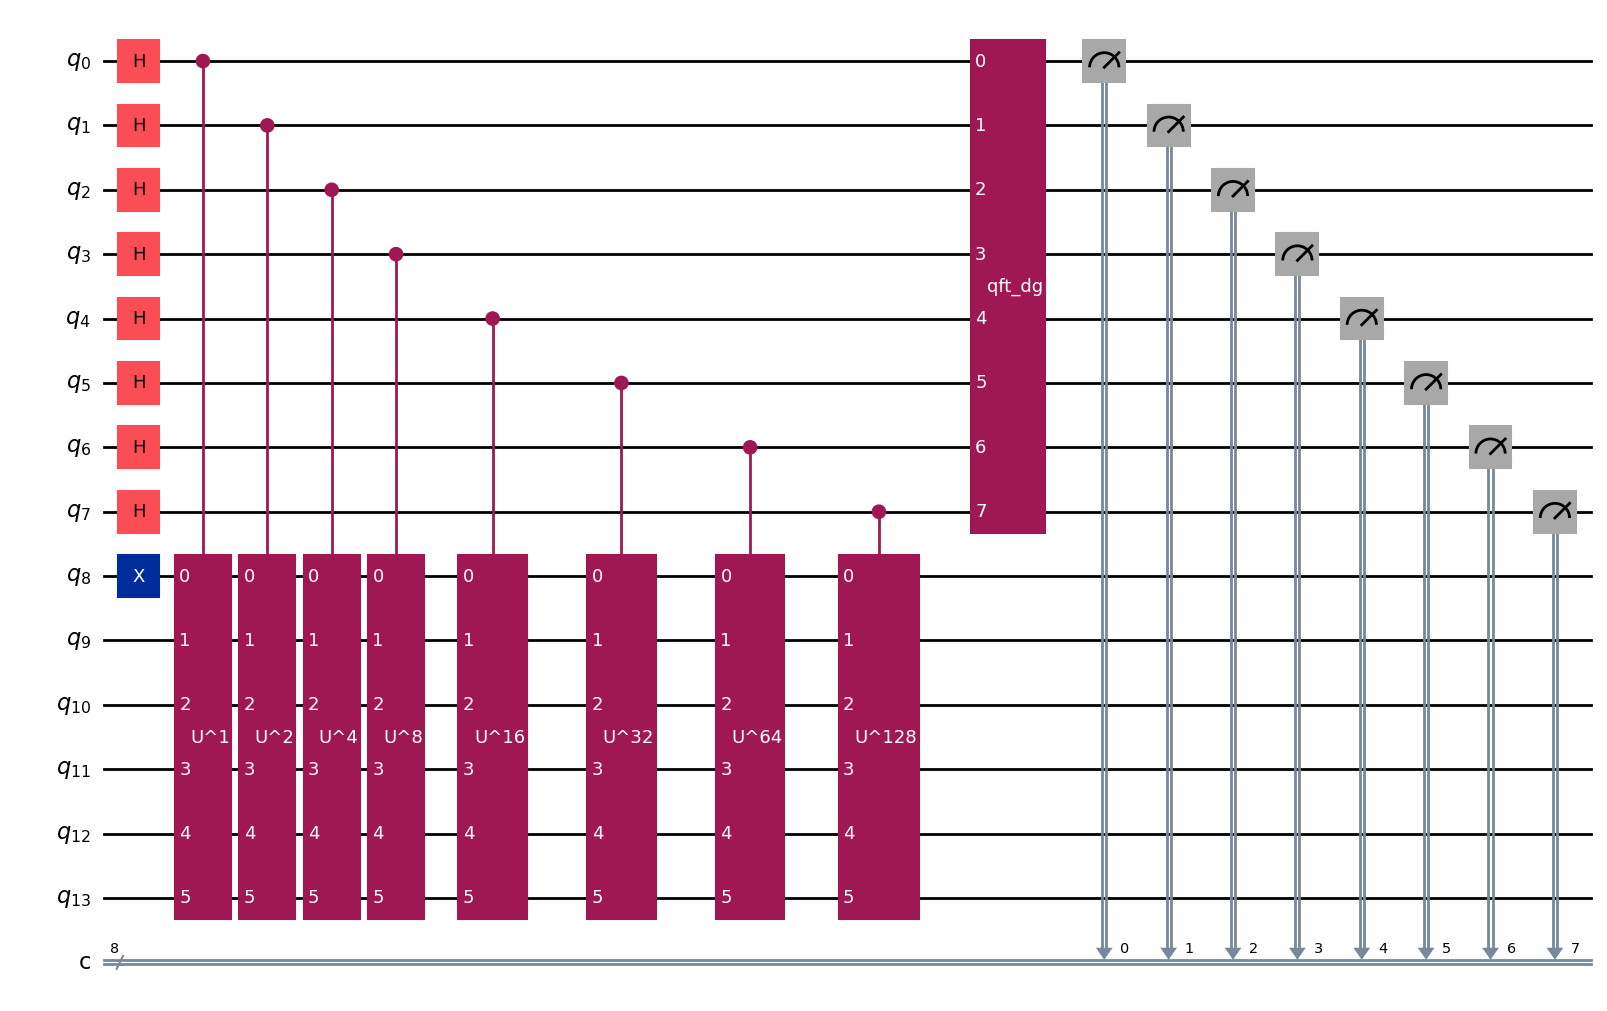

  Estimated order r=12
  Found factors: 7 x 5

Result: 35 = 7 x 5


In [17]:
N = 35
known_a = 2  # set to None to let the algorithm pick random bases

print(f"Factoring N = {N} using Shor's algorithm")
print(f"Using provided a = {known_a}\n")

p, q = shors_algorithm(N, n_count=8, shots=2048, seed=0, max_attempts=15, a=known_a)

if p is not None:
    print(f"\nResult: {N} = {p} x {q}")
    assert p * q == N, "Sanity check failed!"
else:
    print("Shor's algorithm did not find factors in the allotted attempts.")

So as we can see we find the right order r=12 for a =2 mod 35. This then allows us to find our factors of 35 using the second part of shor's algorithm which relies on the fact that if we have an order r such that a^r = 1 mod N, then we can find factors of N by looking at gcd(a^(r/2) ± 1, N). We can also see that our circuit for order finding is exactly the same as the one we had for phase estimation (the modification we made to our code is strictly about output and not assuming we know the order in advance). 